   age workclass  fnlwgt     education  education.num marital.status  \
0   90         ?   77053       HS-grad              9        Widowed   
1   82   Private  132870       HS-grad              9        Widowed   
2   66         ?  186061  Some-college             10        Widowed   
3   54   Private  140359       7th-8th              4       Divorced   
4   41   Private  264663  Some-college             10      Separated   

          occupation   relationship   race     sex  capital.gain  \
0                  ?  Not-in-family  White  Female             0   
1    Exec-managerial  Not-in-family  White  Female             0   
2                  ?      Unmarried  Black  Female             0   
3  Machine-op-inspct      Unmarried  White  Female             0   
4     Prof-specialty      Own-child  White  Female             0   

   capital.loss  hours.per.week native.country income  
0          4356              40  United-States  <=50K  
1          4356              18  United-States

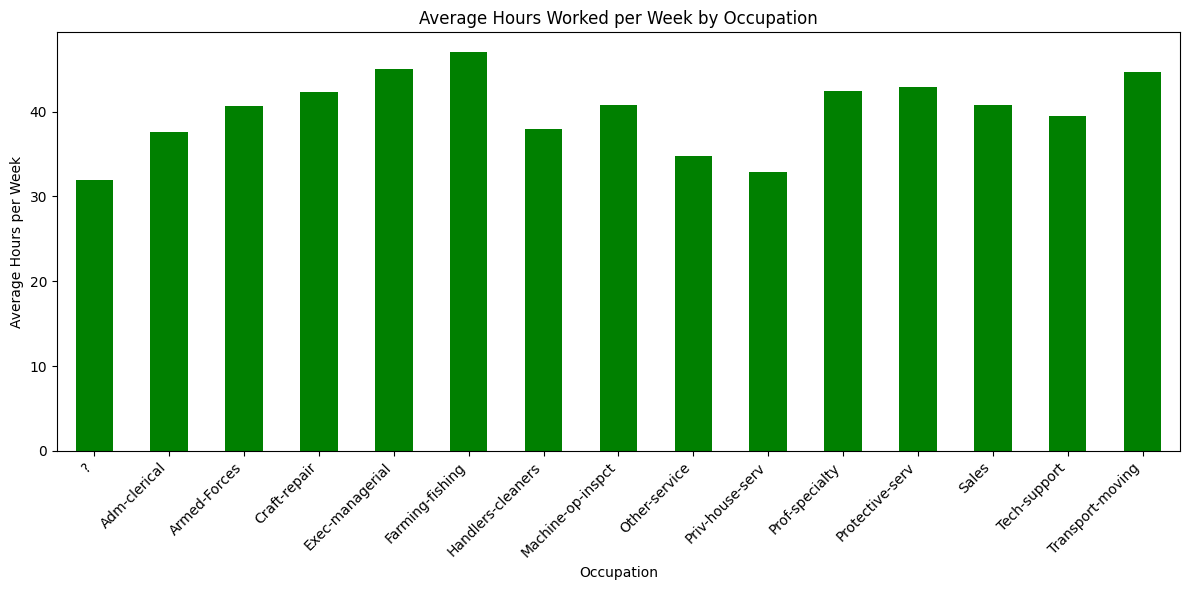

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv("adult.csv")

print(df.head())

# Calculate average hours per week for each occupation
avg_hours = df.groupby("occupation")["hours.per.week"].mean()
print("\nAverage Hours per Week by Occupation:")
print(avg_hours)
# bar chart
plt.figure(figsize=(12, 6))
avg_hours.plot(kind="bar", color="green")

# Chart labels
plt.xlabel("Occupation")
plt.ylabel("Average Hours per Week")
plt.title("Average Hours Worked per Week by Occupation")
#occupation names readable
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()



Income Category Counts:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


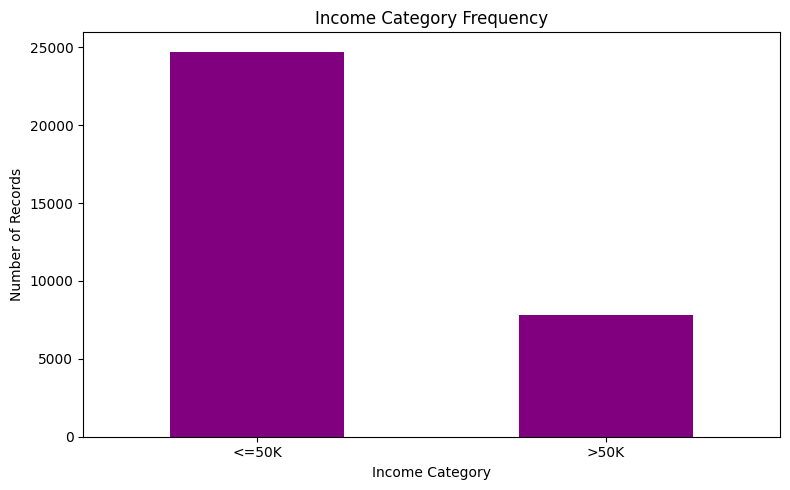

In [ ]:
df = pd.read_csv("adult.csv")
# Count the number of records in each income category
income_counts = df["income"].value_counts()
print("Income Category Counts:")
print(income_counts)

#count plot
plt.figure(figsize=(8, 5))
income_counts.plot(kind="bar",color="purple")

#labels and title
plt.xlabel("Income Category")
plt.ylabel("Number of Records")
plt.title("Income Category Frequency")

# category labels horizontal
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

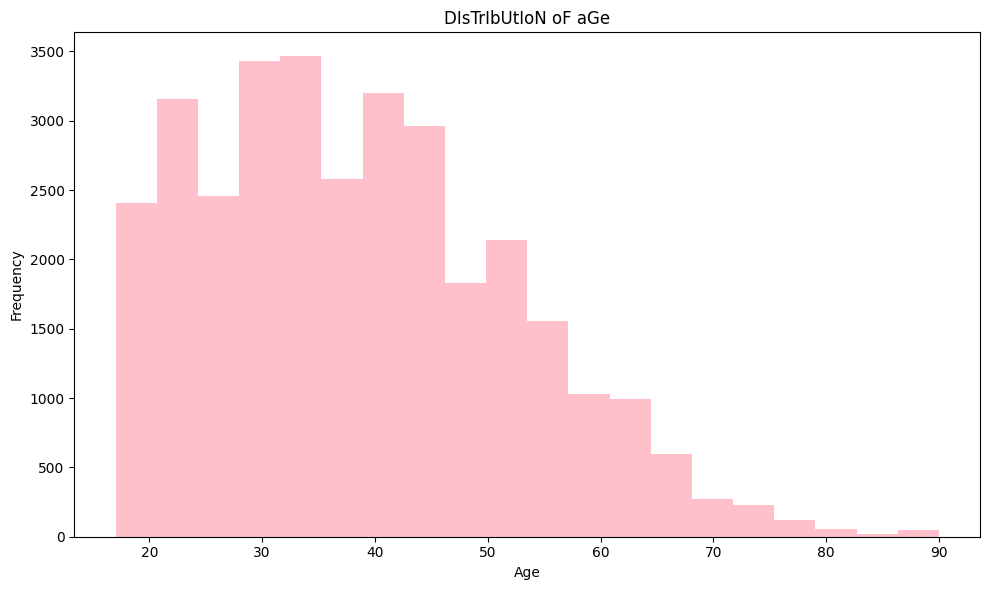

In [ ]:
# histogram of age
plt.figure(figsize=(10, 6))

plt.hist(df["age"], bins=20, color="pink")

# Add labels and title
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.title("DIsTrIbUtIoN oF aGe")
plt.tight_layout()
plt.show()

#this is right skewed.

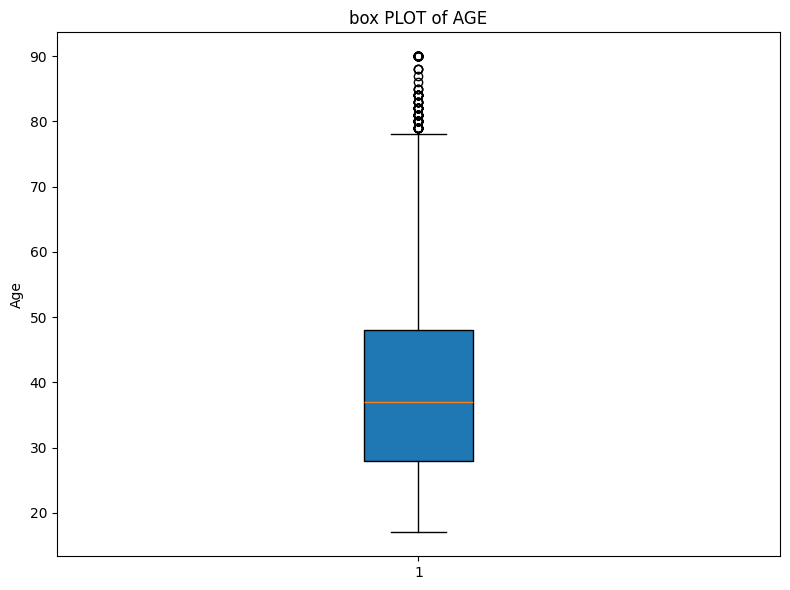

In [ ]:
#  box plot for age
plt.figure(figsize=(8, 6))
plt.boxplot(df["age"], patch_artist=True)
# Labels and title
plt.ylabel("Age")
plt.title("box PLOT of AGE")
plt.tight_layout()
plt.show()

In [ ]:
age = df["age"]
# Calculate Q1 and Q3
Q1 = age.quantile(0.25)
Q3 = age.quantile(0.75)
IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# outliers
outliers = df[(df["age"] < lower) | (df["age"] > upper)]
print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Lower Bound:", lower)
print("Upper Bound:", upper)
print("\nNumber of Outliers:", len(outliers))


Q1: 28.0
Q3: 48.0
IQR: 20.0
Lower Bound: -2.0
Upper Bound: 78.0

Number of Outliers: 143


In Task 4, the box plot showed several outlier points beyond the upper whisker. In Task 5, the IQR method identified exactly 143 outliers, with the upper bound equal to 78. Therefore, the visual observation from the box plot is consistent with the IQR calculation, although the exact number of points is easier to determine using the IQR method.

In [23]:
from scipy import stats
# Calculate z-scores
df["zscore"] = stats.zscore(df["age"])
# Find outliers
outliers_z = df[df["zscore"].abs() > 3]
print("Number of Z-score outliers:", len(outliers_z))

Number of Z-score outliers: 121


No, they are not the same. IQR finds more outliers because the age column is right-skewed.

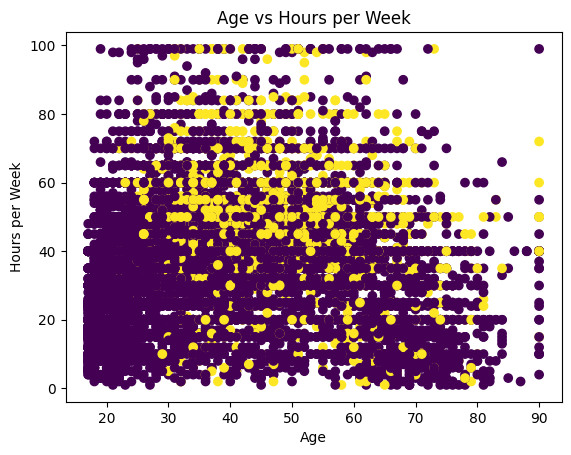

In [25]:
plt.scatter(df["age"], df["hours.per.week"], c=df["income"].astype("category").cat.codes)

plt.xlabel("Age")
plt.ylabel("Hours per Week")
plt.title("Age vs Hours per Week")

plt.show()

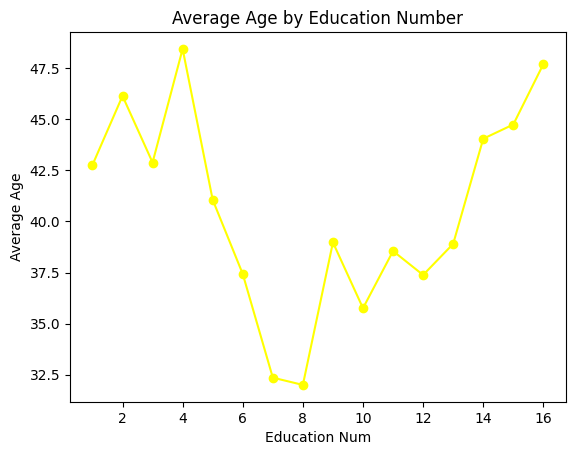

In [31]:
average_age = df.groupby("education.num")["age"].mean()

plt.plot(average_age.index, average_age.values,
         marker="o", color="yellow")

plt.xlabel("Education Num")
plt.ylabel("Average Age")
plt.title("Average Age by Education Number")
plt.show()

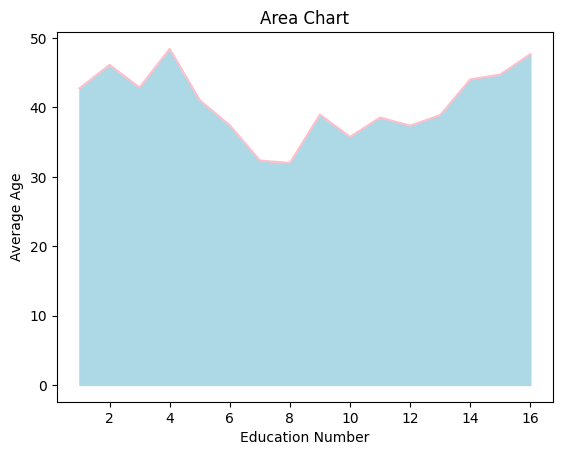

In [30]:
plt.fill_between(average_age.index, average_age.values,
                 color="lightblue")

plt.plot(average_age.index, average_age.values,
         color="pink")

plt.xlabel("Education Number")
plt.ylabel("Average Age")
plt.title("Area Chart")

plt.show()

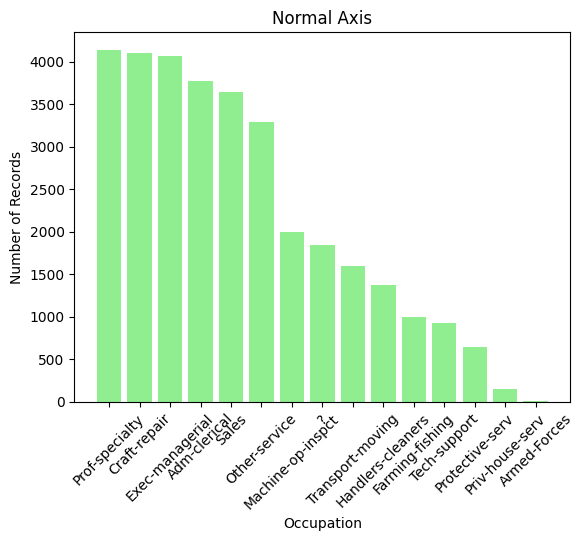

In [37]:
counts = df["occupation"].value_counts()

plt.bar(counts.index, counts.values, color="lightgreen")

plt.xlabel("Occupation")
plt.ylabel("Number of Records")
plt.title("Normal Axis")
plt.xticks(rotation=45)
plt.ylim(0)
plt.show()

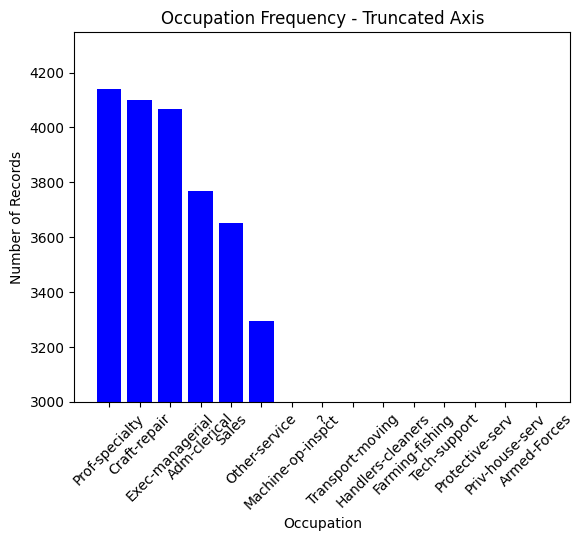

In [36]:
plt.bar(counts.index, counts.values, color="blue")

plt.xlabel("Occupation")
plt.ylabel("Number of Records")
plt.title("Truncated Axis")
plt.xticks(rotation=45)
plt.ylim(3000)
plt.show()

The truncated y-axis exaggerates the differences between occupations. Starting the y-axis from zero provides a more accurate and fair comparison.
